# Leakage Check

In [7]:
import pandas as pd
import torch
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# === Load Model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# === Shared Prompt Function
def query_flan(prompt, max_tokens=32):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(**inputs, max_new_tokens=max_tokens)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

# === Method 1
def method_1_partial_recall(df):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        keyword = row["Keyword"]
        prompt = f"Fill in the missing word: '[{keyword[0]}___]'. It is a common German preposition."
        output = query_flan(prompt)
        results.append({"keyword": keyword, "recovered": keyword.lower() in output.lower(), "model_output": output})
    return pd.DataFrame(results)

# === Method 2
def method_2_fake_vs_real(df):
    fake_keywords = ["abvon", "jeztlich", "bezeug", "zumaln", "entunter", "durchhin", "alben", "überzu"]
    real_results, fake_results = [], []

    for kw in tqdm(df["Keyword"], desc="Real"):
        prompt = f"Complete the German preposition: '[{kw[0]}___]'"
        output = query_flan(prompt)
        real_results.append((kw, kw.lower() in output.lower()))

    for fk in tqdm(fake_keywords, desc="Fake"):
        prompt = f"Complete the German preposition: '[{fk[0]}___]'"
        output = query_flan(prompt)
        fake_results.append((fk, fk.lower() in output.lower()))

    return (
        pd.DataFrame(real_results, columns=["keyword", "recovered"]),
        pd.DataFrame(fake_results, columns=["keyword", "recovered"])
    )

# === Method 3
def method_3_next_in_score(df, sample_size=5):
    grouped = df.groupby("Score")
    predictions = []
    for score, group in grouped:
        keywords = group["Keyword"].tolist()
        context = ", ".join(random.sample(keywords, min(len(keywords), sample_size)))
        prompt = f"Here are some prepositions with grammaticalization score {score}: {context}. What could be another one?"
        output = query_flan(prompt)
        predictions.append({"Score": score, "Prompt": prompt, "ModelPrediction": output})
    return pd.DataFrame(predictions)

# === Method 4
def method_4_predict_score(df):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        keyword = row["Keyword"]
        true_score = row["Score"]
        prompt = f"What is the grammaticalization level of the German preposition '{keyword}'?\nRespond with a number from 1 (very low) to 4 (very high)."
        output = query_flan(prompt)
        try:
            pred_score = int([s for s in output if s in "1234"][-1])
        except:
            pred_score = None
        results.append({"keyword": keyword, "true_score": true_score, "predicted_score": pred_score, "model_output": output})
    return pd.DataFrame(results)

# === Evaluation + Plotting Functions

def evaluate_method_1(results_1, output_csv="method1_partial_recall_flant5.csv"):
    acc = results_1["recovered"].mean()
    df = pd.DataFrame([{"Method": "Partial Keyword Recall", "Metric": "Recovery Rate", "Value": acc}])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_2(real_df, fake_df, output_csv="method2_real_vs_fake_flant5.csv"):
    acc_real = real_df["recovered"].mean()
    acc_fake = fake_df["recovered"].mean()
    diff = acc_real - acc_fake
    df = pd.DataFrame([
        {"Method": "Real Keyword Recovery", "Metric": "Recovery Rate", "Value": acc_real},
        {"Method": "Fake Keyword Recovery", "Metric": "Recovery Rate", "Value": acc_fake},
        {"Method": "Real vs Fake Difference", "Metric": "Real - Fake", "Value": diff}
    ])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_3(score_predictions, test_df, output_csv="method3_group_prediction_flant5.csv"):
    keyword_set = set(score_predictions["ModelPrediction"].str.lower())
    match_count = test_df["Keyword"].str.lower().isin(keyword_set).sum()
    coverage = match_count / len(test_df)
    df = pd.DataFrame([
        {"Method": "Score-Based Next Prediction", "Metric": "Keyword Recall (approx)", "Value": coverage}
    ])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_4(score_guesses, output_csv="method4_score_prediction_flant5.csv"):
    score_guesses = score_guesses.dropna(subset=["predicted_score"])
    grouped = score_guesses.groupby("true_score")
    metrics = []
    for score, group in grouped:
        acc = (group["true_score"] == group["predicted_score"]).mean()
        metrics.append({"Method": f"Score Prediction (Score={score})", "Metric": "Accuracy", "Value": acc})
    overall_acc = (score_guesses["true_score"] == score_guesses["predicted_score"]).mean()
    metrics.append({"Method": "Score Prediction Overall", "Metric": "Accuracy", "Value": overall_acc})
    df = pd.DataFrame(metrics)
    df.to_csv(output_csv, index=False)
    return df

# === Plotting for Each Method

def plot_method_1(df):
    val = df.loc[0, "Value"]
    plt.figure(figsize=(5, 4))
    plt.bar(["Partial Recall"], [val], color="#9467bd")
    plt.ylim(0, 1)
    plt.ylabel("Recovery Rate")
    plt.title("Method 1: Partial Keyword Recall")
    plt.text(0, val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()

def plot_method_2(df):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(df["Method"], df["Value"], color=["#2ca02c", "#d62728", "#888888"])
    plt.ylim(0, 1)
    plt.ylabel("Recovery Rate")
    plt.title("Method 2: Real vs Fake Keyword Recovery")
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2%}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

def plot_method_3(df):
    val = df.loc[0, "Value"]
    plt.figure(figsize=(5, 4))
    plt.bar(["Keyword Coverage"], [val], color="#ff7f0e")
    plt.ylim(0, 1)
    plt.ylabel("Match Rate")
    plt.title("Method 3: Score-Based Prediction Match")
    plt.text(0, val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()

def plot_method_4(df):
    score_df = df[df["Method"].str.contains("Score=")].copy()
    score_df["Score"] = score_df["Method"].str.extract(r"Score=(\d)").astype(int)
    plt.figure(figsize=(8, 5))
    plt.bar(score_df["Score"], score_df["Value"], color="#1f77b4")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.xticks(score_df["Score"])
    plt.title("Method 4: Score Prediction Accuracy per Level")
    for i, val in enumerate(score_df["Value"]):
        plt.text(score_df["Score"].iloc[i], val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()

# === Master Run Function ===

def run_full_leakage_analysis_pipeline(df):
    results_1 = method_1_partial_recall(df)
    real_df, fake_df = method_2_fake_vs_real(df)
    score_predictions = method_3_next_in_score(df)
    score_guesses = method_4_predict_score(df)

    df1 = evaluate_method_1(results_1)
    plot_method_1(df1)

    df2 = evaluate_method_2(real_df, fake_df)
    plot_method_2(df2)

    df3 = evaluate_method_3(score_predictions, df)
    plot_method_3(df3)

    df4 = evaluate_method_4(score_guesses)
    plot_method_4(df4)

    return df1, df2, df3, df4


100%|██████████| 235/235 [00:12<00:00, 18.34it/s]


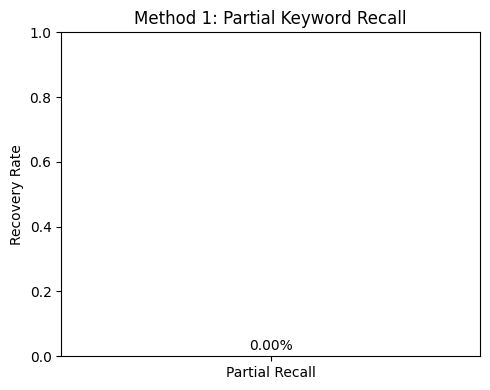

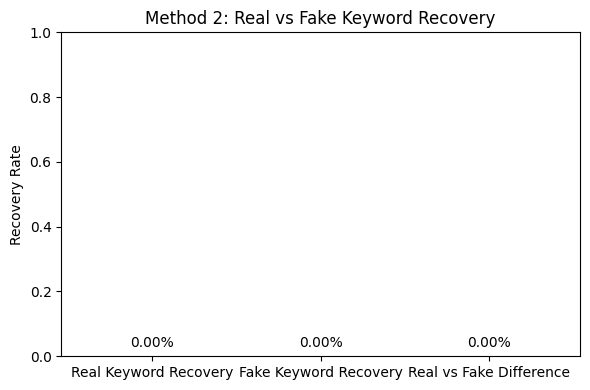

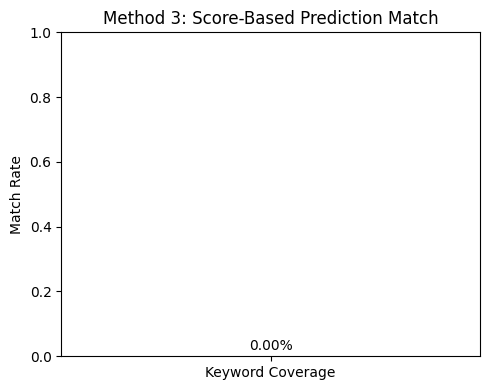

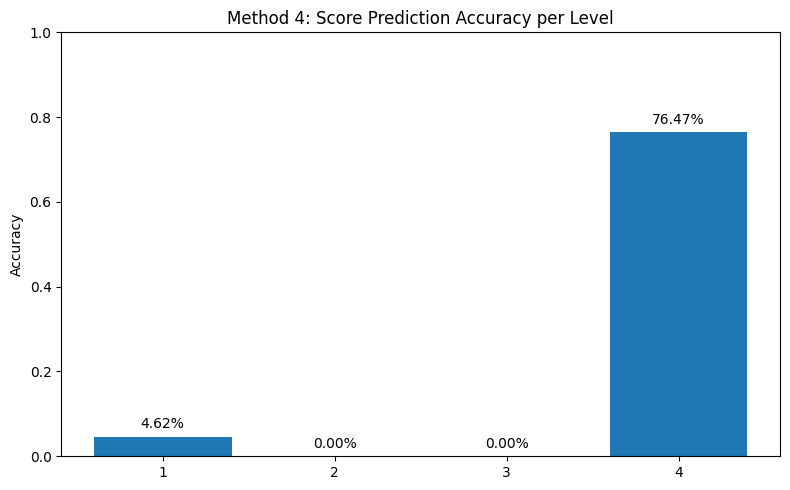

In [8]:
# Load your testset.csv
df = pd.read_csv("testset.csv")
df.columns = df.columns.str.strip()

# Run full pipeline
df1, df2, df3, df4 = run_full_leakage_analysis_pipeline(df)


In [9]:
!pip install -q transformers accelerate

import pandas as pd
import torch
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load TinyLlama model
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

def query_model(prompt, max_tokens=32):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    output = model.generate(input_ids, max_new_tokens=max_tokens, do_sample=False)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    return decoded[len(prompt):].strip()

In [10]:
# === Method 1: Partial keyword recall
def method_1_partial_recall(df):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        keyword = row["Keyword"]
        prompt = f"Fill in the missing word: '[{keyword[0]}___]'. It is a common German preposition."
        output = query_model(prompt)
        results.append({
            "keyword": keyword,
            "recovered": keyword.lower() in output.lower(),
            "model_output": output
        })
    return pd.DataFrame(results)
# === Method 2: Real vs Fake keyword recovery
def method_2_fake_vs_real(df):
    fake_keywords = ["abvon", "jeztlich", "bezeug", "zumaln", "entunter", "durchhin", "alben", "überzu"]
    real_results, fake_results = [], []

    for kw in tqdm(df["Keyword"], desc="Real"):
        prompt = f"Complete the German preposition: '[{kw[0]}___]'"
        output = query_model(prompt)
        real_results.append((kw, kw.lower() in output.lower()))

    for fk in tqdm(fake_keywords, desc="Fake"):
        prompt = f"Complete the German preposition: '[{fk[0]}___]'"
        output = query_model(prompt)
        fake_results.append((fk, fk.lower() in output.lower()))

    return (
        pd.DataFrame(real_results, columns=["keyword", "recovered"]),
        pd.DataFrame(fake_results, columns=["keyword", "recovered"])
    )
# === Method 3: Predict next keyword from score group
def method_3_next_in_score(df, sample_size=5):
    grouped = df.groupby("Score")
    predictions = []
    for score, group in grouped:
        keywords = group["Keyword"].tolist()
        context = ", ".join(random.sample(keywords, min(len(keywords), sample_size)))
        prompt = f"Here are some prepositions with grammaticalization score {score}: {context}. Suggest another:"
        output = query_model(prompt)
        predictions.append({"Score": score, "Prompt": prompt, "ModelPrediction": output})
    return pd.DataFrame(predictions)
# === Method 4: Predict score from keyword
def method_4_predict_score(df):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        keyword = row["Keyword"]
        true_score = row["Score"]
        prompt = (
            f"What is the grammaticalization score (1-4) of the German preposition '{keyword}'?"
        )
        output = query_model(prompt)
        try:
            pred_score = int([s for s in output if s in "1234"][-1])
        except:
            pred_score = None
        results.append({
            "keyword": keyword,
            "true_score": true_score,
            "predicted_score": pred_score,
            "model_output": output
        })
    return pd.DataFrame(results)


In [11]:
# === EVALUATION FUNCTIONS ===

def evaluate_method_1(results_1, output_csv="method1_partial_recall_tinyllama.csv"):
    acc = results_1["recovered"].mean()
    df = pd.DataFrame([{"Method": "Partial Keyword Recall", "Metric": "Recovery Rate", "Value": acc}])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_2(real_df, fake_df, output_csv="method2_real_vs_fake_tinyllama.csv"):
    acc_real = real_df["recovered"].mean()
    acc_fake = fake_df["recovered"].mean()
    diff = acc_real - acc_fake
    df = pd.DataFrame([
        {"Method": "Real Keyword Recovery", "Metric": "Recovery Rate", "Value": acc_real},
        {"Method": "Fake Keyword Recovery", "Metric": "Recovery Rate", "Value": acc_fake},
        {"Method": "Real vs Fake Difference", "Metric": "Real - Fake", "Value": diff}
    ])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_3(score_predictions, test_df, output_csv="method3_group_prediction_tinyllama.csv"):
    keyword_set = set(score_predictions["ModelPrediction"].str.lower())
    match_count = test_df["Keyword"].str.lower().isin(keyword_set).sum()
    coverage = match_count / len(test_df)
    df = pd.DataFrame([
        {"Method": "Score-Based Next Prediction", "Metric": "Keyword Recall (approx)", "Value": coverage}
    ])
    df.to_csv(output_csv, index=False)
    return df

def evaluate_method_4(score_guesses, output_csv="method4_score_prediction_tinyllama.csv"):
    score_guesses = score_guesses.dropna(subset=["predicted_score"])
    grouped = score_guesses.groupby("true_score")
    metrics = []
    for score, group in grouped:
        acc = (group["true_score"] == group["predicted_score"]).mean()
        metrics.append({"Method": f"Score Prediction (Score={score})", "Metric": "Accuracy", "Value": acc})
    overall_acc = (score_guesses["true_score"] == score_guesses["predicted_score"]).mean()
    metrics.append({"Method": "Score Prediction Overall", "Metric": "Accuracy", "Value": overall_acc})
    df = pd.DataFrame(metrics)
    df.to_csv(output_csv, index=False)
    return df
def plot_method_1(df):
    val = df.loc[0, "Value"]
    plt.figure(figsize=(5, 4))
    plt.bar(["Partial Recall"], [val], color="#9467bd")
    plt.ylim(0, 1)
    plt.ylabel("Recovery Rate")
    plt.title("Method 1: Partial Keyword Recall")
    plt.text(0, val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()

def plot_method_2(df):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(df["Method"], df["Value"], color=["#2ca02c", "#d62728", "#888888"])
    plt.ylim(0, 1)
    plt.ylabel("Recovery Rate")
    plt.title("Method 2: Real vs Fake Keyword Recovery")
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2%}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

def plot_method_3(df):
    val = df.loc[0, "Value"]
    plt.figure(figsize=(5, 4))
    plt.bar(["Keyword Coverage"], [val], color="#ff7f0e")
    plt.ylim(0, 1)
    plt.ylabel("Match Rate")
    plt.title("Method 3: Score-Based Prediction Match")
    plt.text(0, val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()

def plot_method_4(df):
    score_df = df[df["Method"].str.contains("Score=")].copy()
    score_df["Score"] = score_df["Method"].str.extract(r"Score=(\d)").astype(int)
    plt.figure(figsize=(8, 5))
    plt.bar(score_df["Score"], score_df["Value"], color="#1f77b4")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.xticks(score_df["Score"])
    plt.title("Method 4: Score Prediction Accuracy per Level")
    for i, val in enumerate(score_df["Value"]):
        plt.text(score_df["Score"].iloc[i], val + 0.02, f"{val:.2%}", ha='center')
    plt.tight_layout()
    plt.show()
def run_full_leakage_analysis_pipeline(df):
    results_1 = method_1_partial_recall(df)
    real_df, fake_df = method_2_fake_vs_real(df)
    score_predictions = method_3_next_in_score(df)
    score_guesses = method_4_predict_score(df)

    df1 = evaluate_method_1(results_1)
    plot_method_1(df1)

    df2 = evaluate_method_2(real_df, fake_df)
    plot_method_2(df2)

    df3 = evaluate_method_3(score_predictions, df)
    plot_method_3(df3)

    df4 = evaluate_method_4(score_guesses)
    plot_method_4(df4)

    return df1, df2, df3, df4


100%|██████████| 235/235 [00:08<00:00, 28.47it/s]


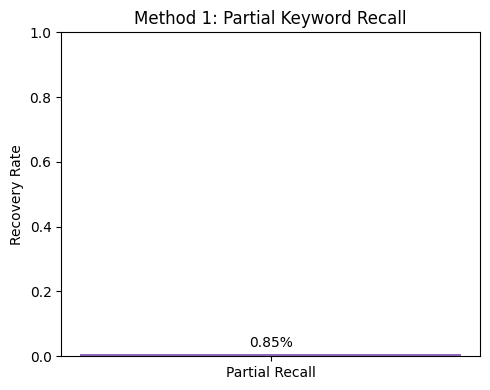

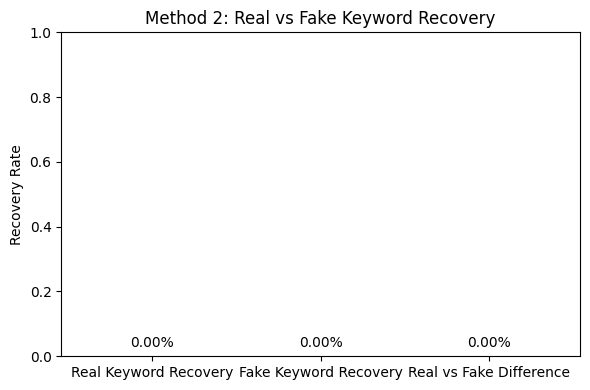

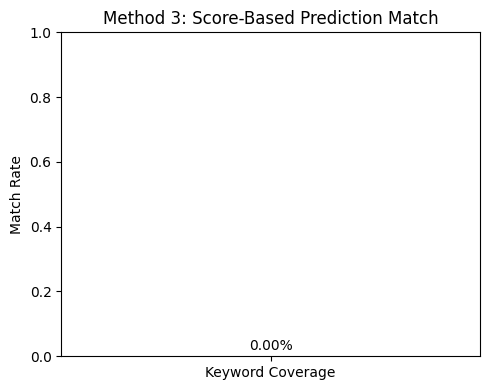

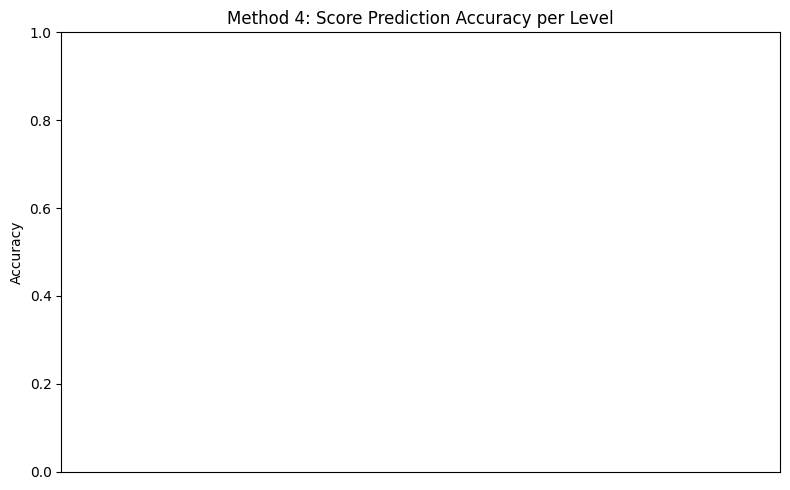

In [12]:
df = pd.read_csv("testset.csv")
df.columns = df.columns.str.strip()

df1, df2, df3, df4 = run_full_leakage_analysis_pipeline(df)
